In [1]:
import os
import sys
src_dir = os.path.join(os.getcwd(), '..', 'src' )
sys.path.append(src_dir)
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from etl.etl import ETL
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('train.csv')
train

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,city
0,2013-01-02,0,59,22154,999.00,1.0,явление 2012 bd,37,Кино - Blu-Ray,ярославль тц альтаир,ярославль
1,2013-01-03,0,25,2552,899.00,1.0,deep purple the house of blue light lp,58,Музыка - Винил,москва трк атриум,москва
2,2013-01-06,0,25,2554,1709.05,1.0,deep purple who do you think we are lp,58,Музыка - Винил,москва трк атриум,москва
3,2013-01-15,0,25,2555,1099.00,1.0,deep purple 30 very best of 2cd фирм,56,Музыка - CD фирменного производства,москва трк атриум,москва
4,2013-01-10,0,25,2564,349.00,1.0,deep purple perihelion live in concert dvd кир,59,Музыка - Музыкальное видео,москва трк атриум,москва
...,...,...,...,...,...,...,...,...,...,...,...
3127514,2015-10-10,33,25,7409,299.00,1.0,va nu jazz selection digipack,55,Музыка - CD локального производства,москва трк атриум,москва
3127515,2015-10-09,33,25,7460,299.00,1.0,va the golden jazz collection 1 2cd,55,Музыка - CD локального производства,москва трк атриум,москва
3127516,2015-10-14,33,25,7459,349.00,1.0,va the best of the 3 tenors,55,Музыка - CD локального производства,москва трк атриум,москва
3127517,2015-10-22,33,25,7440,299.00,1.0,va relax collection planet mp3 mp3cd jewel,57,Музыка - MP3,москва трк атриум,москва


In [3]:
train['date'] = pd.to_datetime(train['date'])
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['week'] = train['date'].dt.isocalendar().week
train['day_of_week'] = train['date'].dt.day_of_week
train['period'] = train['year'].astype(str) + '-' + train['month'].astype(str).str.zfill(2)
train.head(5)


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,city,year,month,week,day_of_week,period
0,2013-01-02,0,59,22154,999.00,1.0,явление 2012 bd,37,Кино - Blu-Ray,ярославль тц альтаир,ярославль,2013,1,1,2,2013-01
1,2013-01-03,0,25,2552,899.00,1.0,deep purple the house of blue light lp,58,Музыка - Винил,москва трк атриум,москва,2013,1,1,3,2013-01
2,2013-01-06,0,25,2554,1709.05,1.0,deep purple who do you think we are lp,58,Музыка - Винил,москва трк атриум,москва,2013,1,1,6,2013-01
3,2013-01-15,0,25,2555,1099.00,1.0,deep purple 30 very best of 2cd фирм,56,Музыка - CD фирменного производства,москва трк атриум,москва,2013,1,3,1,2013-01
4,2013-01-10,0,25,2564,349.00,1.0,deep purple perihelion live in concert dvd кир,59,Музыка - Музыкальное видео,москва трк атриум,москва,2013,1,2,3,2013-01


# 1. General Distributions

## 1.1 *item_cnt_day* distribution

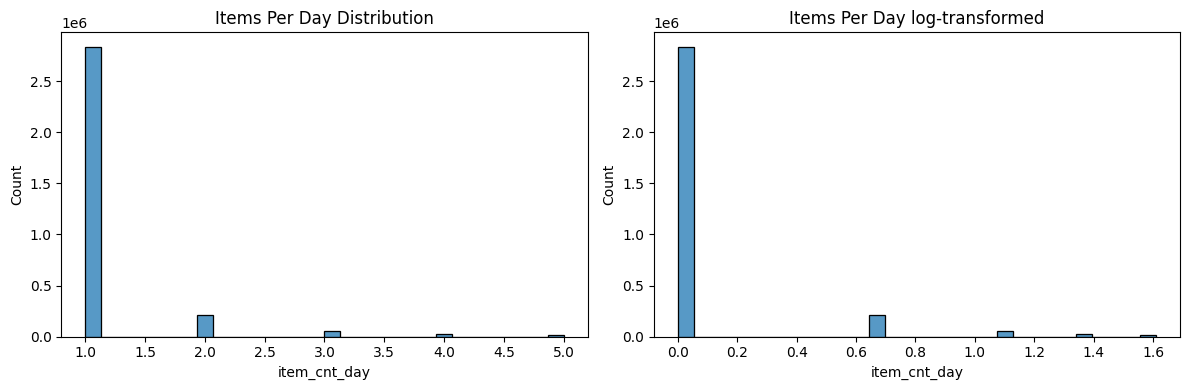

In [4]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

sns.histplot(train['item_cnt_day'], bins=30, ax=axes[0])
axes[0].set_title('Items Per Day Distribution')


sns.histplot(np.log(train['item_cnt_day']), bins=30, ax=axes[1])
axes[1].set_title('Items Per Day log-transformed')


plt.tight_layout()
plt.show()

Observations:
- General distribution reveals some important information: we can clearly see that most items are sold only one time per day (>2.5kk entries), though there's a little spike at 2 items a day (about 250k entries), a small spike at 3 items per day (less than 80k entries) and tiny spikes at 4 and 5 items per day. For better understanding I assume log-transforming.
- Actually log-transormiation did not reveal any new inormation

## 1.2 *item_price* distribution

Now I guess it might be useful to analyse the distribution of item prices so as to see potential patterns or may be think of some feature engineering

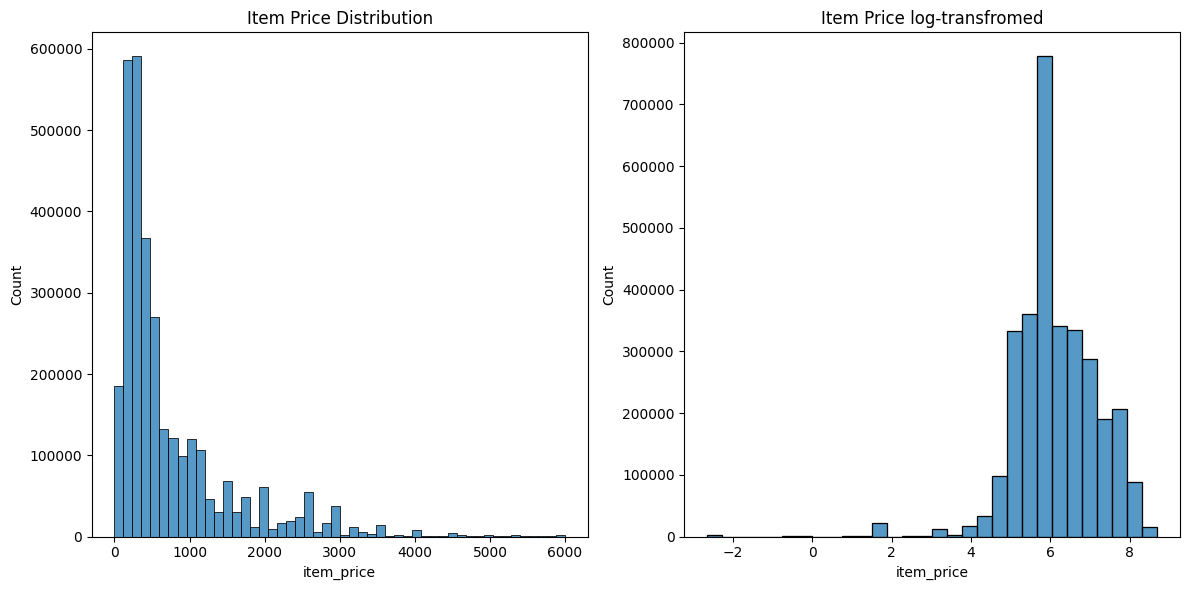

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

sns.histplot(train['item_price'], bins=50, ax=axes[0])
axes[0].set_title('Item Price Distribution')


sns.histplot(np.log(train['item_price']), bins=30, ax=axes[1])
axes[1].set_title('Item Price log-transfromed')

plt.tight_layout()
plt.show()

Observations:
- Generally prices are slightly skewed. We can see a huge spike in [120, 360] price range(1.2kk entries totalyl), big spikes in [360, 600] range (>650k entries) and many other price ranges. Let's do log-transformation and see what happens.
- That reveals some more information, we see a huge concentration of items in logaritmic range of [~4.64, ~8] representing price range of about [100, 2824]

General conclusion: seems like items tend to be grouped by prices and items with lower price seem to be bought much more often

**Feature Engineering Ideas**
- As it was observed prices are somehow 'clustered' and it may be useful to divide them into categorical groups(e.g. low, meidum, high), which might be a good indicator
- It probably makes sense to transform prices, i.e. apply log-transformation or scaling(via MinMaxScaler or StandardScaler). As it was mentioned before, this will reduce the overfitting effect and will simplify optimization

# 2. *item_cnt_day* - *item_price* correlation
It might be useful to understand whether the *item_cnt_day* is really dependant on *item_price*

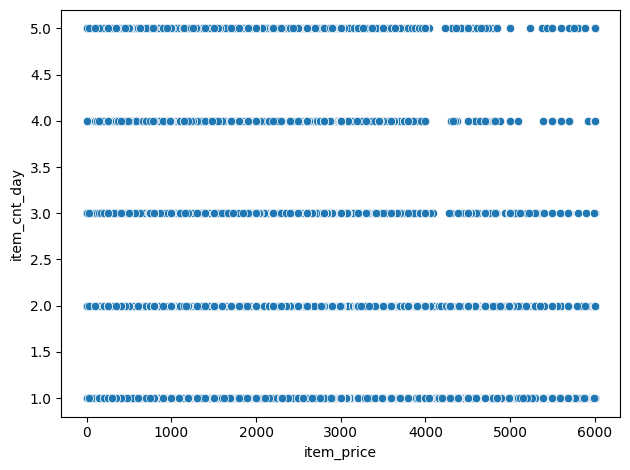

In [36]:

sns.scatterplot(x=train['item_price'], y=train['item_cnt_day'])

plt.tight_layout()
plt.show()

Observations:
- Scatterplot does not reveal any obvious specific correlations, there might be some more complicated dependency though
- We see those 'gaps' which say that items which cost about 4100-4200 are never sold more than twice a day, and items with price ~5200 are never sold more than 3 times a day. I'm not sure if this thing explains any kind of correlations, just keep in mind that some items are more likely to be bought

# 3. Time Series Research
It's now time for one of the most interesting parts - analyzing those strange extreme sales. General preassumption is that we are likely to have some special days (like holidays) when sales tend to go up.

First I'd love to know is there any changes in overall sales throughout time. Therefore doing `groupby` by *period* and sum up *item_cnt_day* 

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


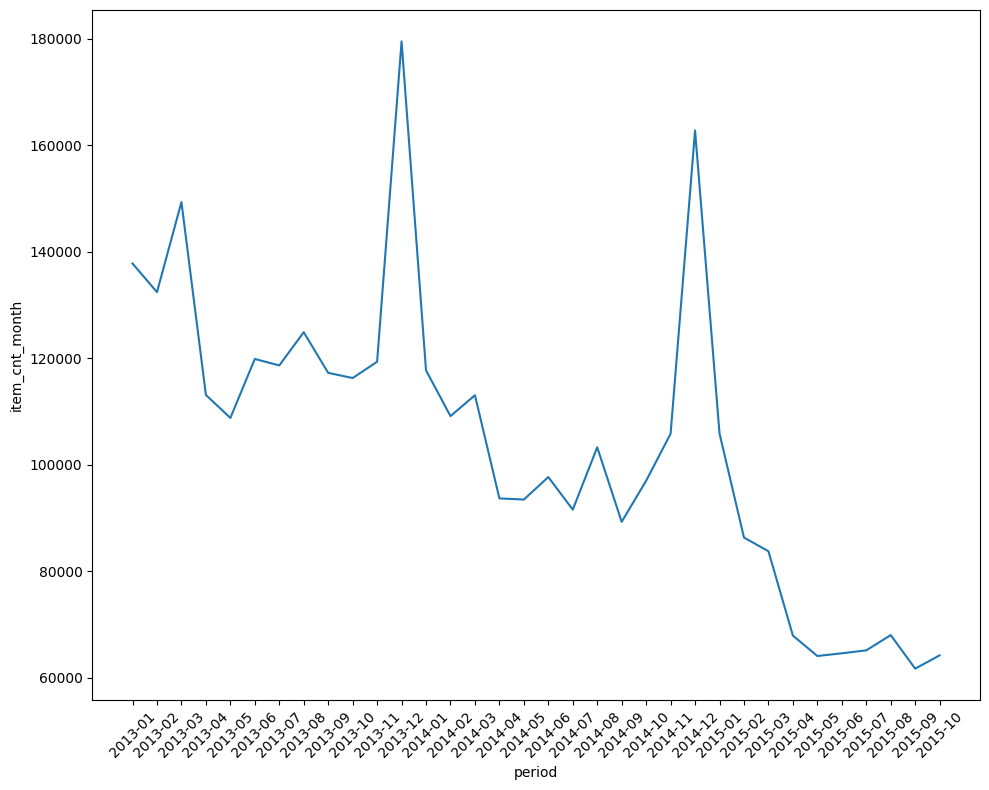

In [37]:
plt.figure(figsize=(10,8))
monthly_sales = train.groupby(['period']).agg({
    'item_cnt_day': 'sum'
}).reset_index().rename(columns={'item_cnt_day':'item_cnt_month'})
sns.lineplot(x=monthly_sales['period'], y=monthly_sales['item_cnt_month'])
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

The initial time series analysis gives us some portion of interesting information

Observations:
- The start point is January 2013 and we can see that sales were about 130k items per month (all shops and all items), the end point is October 2015 and sales are about only 70k items per month. It's obvious that the sales dramatically decreased. So for now we can suppose that generally sales tend to go down.
- Probably the most important thing we can admit is those high peaks in October-November. There are probably a lot of holidays at this period therefore it can be a bit obvious that sales go up, though it's a piece of very important information for us to know.
- Then we can observe those peaks in January-February, might be some holidays as well but in 2015 there was a decrease at this period which is strange. I prefere not to think that 2013 and 2014 had high sales at this period due to holidays.
- Sales tend to be relatively low in spring and seem to go down. 
- Sales tend to go up during summer, might be due to some kind of vacations (or whatever).
- Winter is sort of a strange period, as something happens in December which makes sales go extremely low and I have no idea what it can be.

General conclusion: season of the year seems to be very important for us, as there are specific periods which tend to be repetitive.


**Feature Engineering Ideas**
- *month* might be very informative for us, but not for the model. We now know that sales tend to go extremely high in October-November, then go extremely low in December-January, and be relatively low during summer. The only problem is that we know that January goes right after December, unfortunattely the model will intepret December as 12 and January as 1. See, it's not obvious for the model that January goes right after December. Therefore I suppose we can benefit from circular month representation(i.e. sin and cos)
- We might need an indicatior or something like *is_holiday* for October-November period and *is_winter* for winter extreme decrease.

May be decomposing the time series might give us some external information

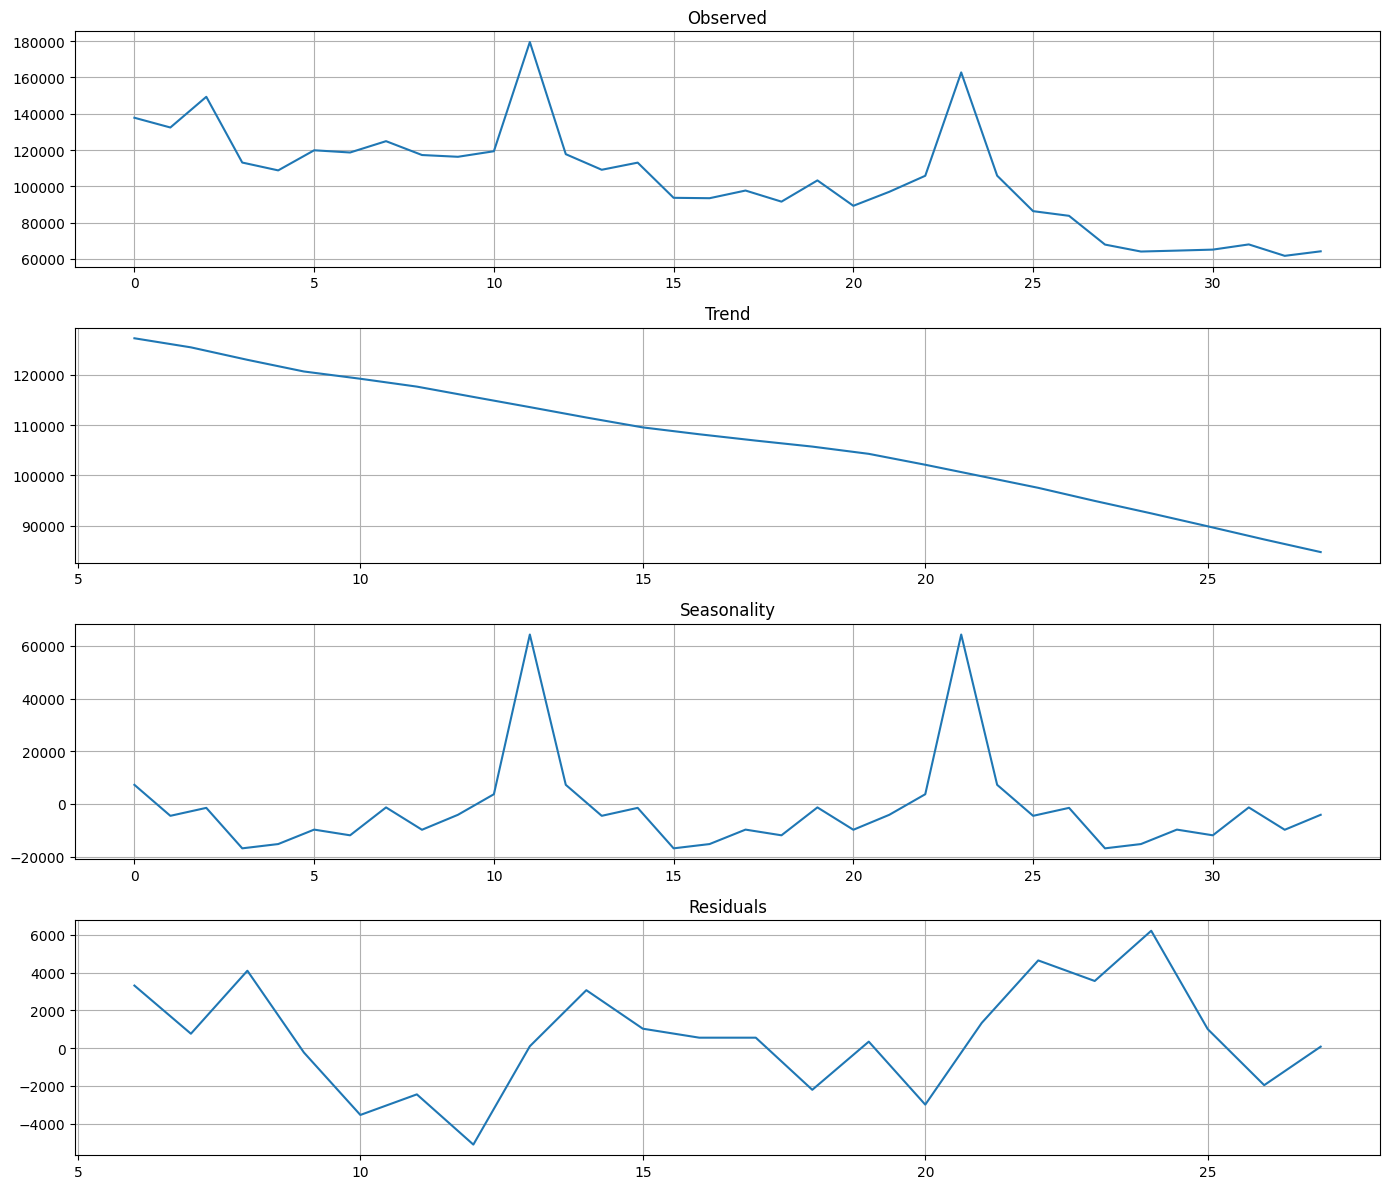

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(monthly_sales['item_cnt_day'], model='additive', period=12)
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residuals')
for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()

Observation:
- The starting point of the sales is 130k items per month, but the end point is under 90k. It's clear that sales tend to decrease over years, therefore we can notice a downgoing trend
- From seasonal component decomposition we learn that sales really have repetitiveness. They tend to go extremely high from month 10 to month 11, and then harshly go down in month 12. We can see a smooth increase before, starting in about month 6.
- The residuals have some kind of stochasticity, i.e. that seasonal and trend decomposition do not totally describe the time series(affected by special random events)

In [9]:
from statsmodels.tsa.stattools import adfuller

adf = adfuller(monthly_sales['item_cnt_day'])
print(f'p-value: {adf[1]}')

p-value: 0.13091376519879322


Observation:
- adfuller p-value is 0.13 which means the time series is non-stationary (p-value <= 0.05 required), need to try deffirencing

In [10]:
adf = adfuller(monthly_sales['item_cnt_day'].diff().dropna())
print(f'p-value: {adf[1]}, used lag: {adf[2]}')

p-value: 4.122390848069216e-28, used lag: 10


Observation:
- Single differencing gives stationarity with p-value equal to 4.12 * 10^-28, additionally we now know that the used lag is 10 (might be important for further forecasting)


Let's now plot differentiated time series and see what happens (maybe we'll plot acf/pacf as well)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


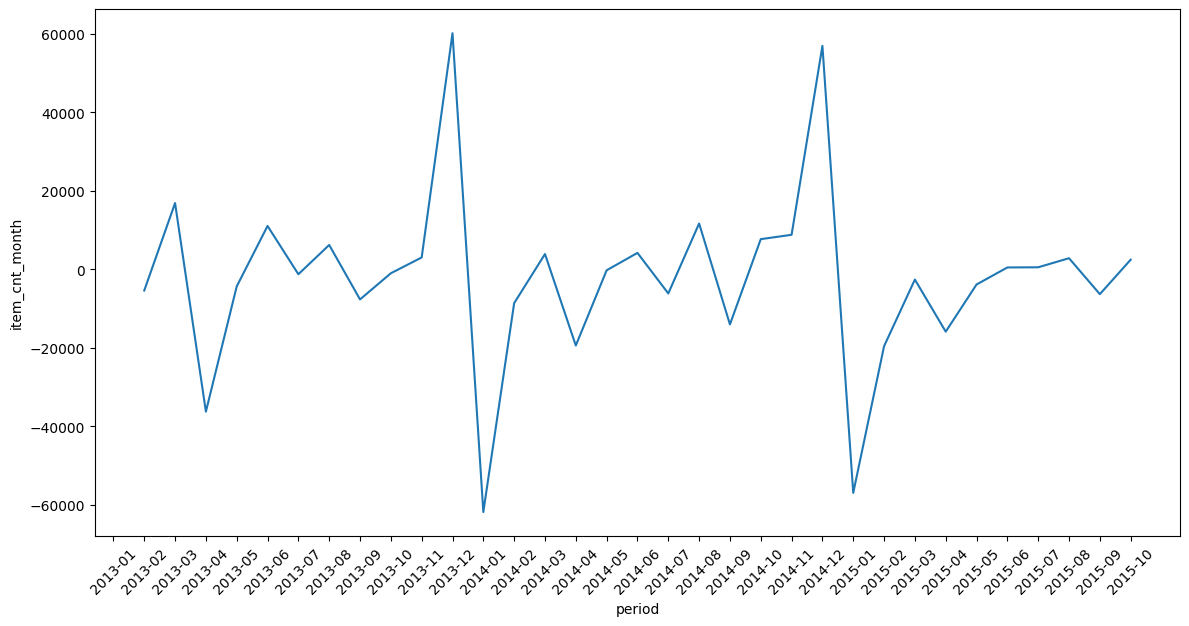

In [40]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_sales['period'], y=monthly_sales['item_cnt_month'].diff().dropna())

plt.tight_layout()
plt.tick_params(axis='x', rotation=45)
plt.show()

Observation:
- What we can actually observe is that we now have stable mean (which means trend removal), but the time series, despite good adf p-value, remains non-stationary. You see those in December, the fluctuations at these points are far larger than at other times, like mid-2013 or mid-2015. This suggests the volatility is not stable. Therefore we have inconstant variance
- Since these spikes appear to be regulat, we did not get rid of seasonality.

Troubleshooting:
- Surfing the net I discovered a good approach to some presented problems, we probably should apply log-transformation, differentiate with respect to the whole year and use 1-st order differencing

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


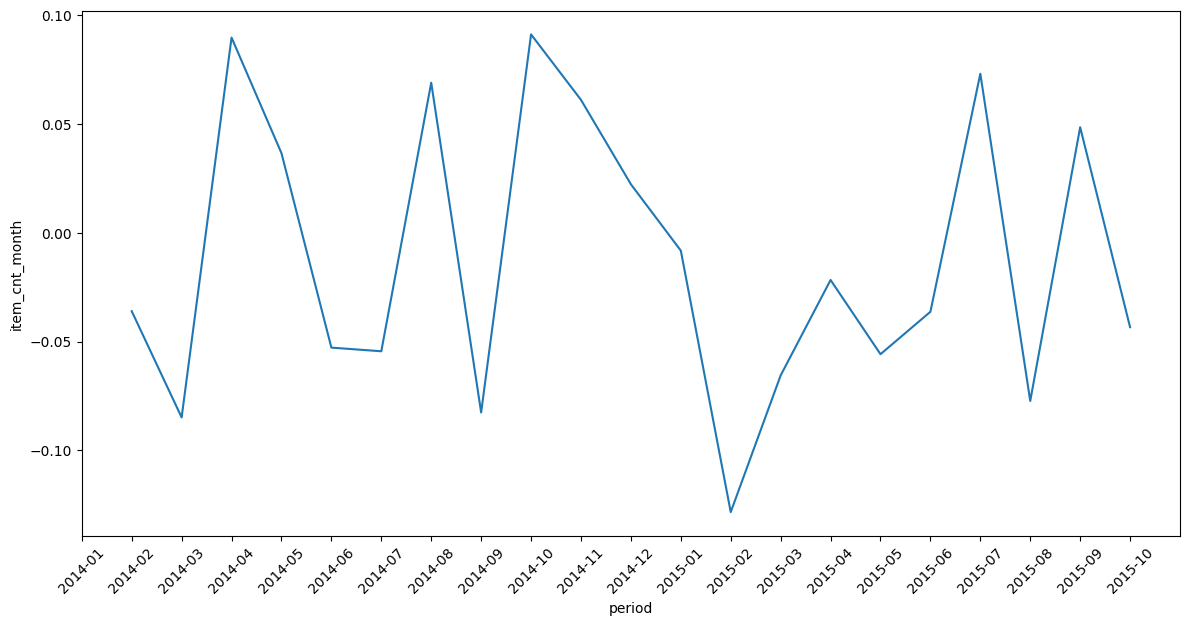

In [45]:
plt.figure(figsize=(12, 6))

stationary_data = np.log(monthly_sales['item_cnt_month']).diff(12).diff(1).dropna()

sns.lineplot(x=monthly_sales['period'], y=stationary_data)

plt.tight_layout()
plt.tick_params('x', rotation=45)
plt.show()

Observation:
- Okay, the time series now seems to be stationary, therefore we can stop transforming it and keep analyzing other patterns

**Feature Engineering Ideas**
- Need to cast *item_cnt_month* feature to its stationary variant

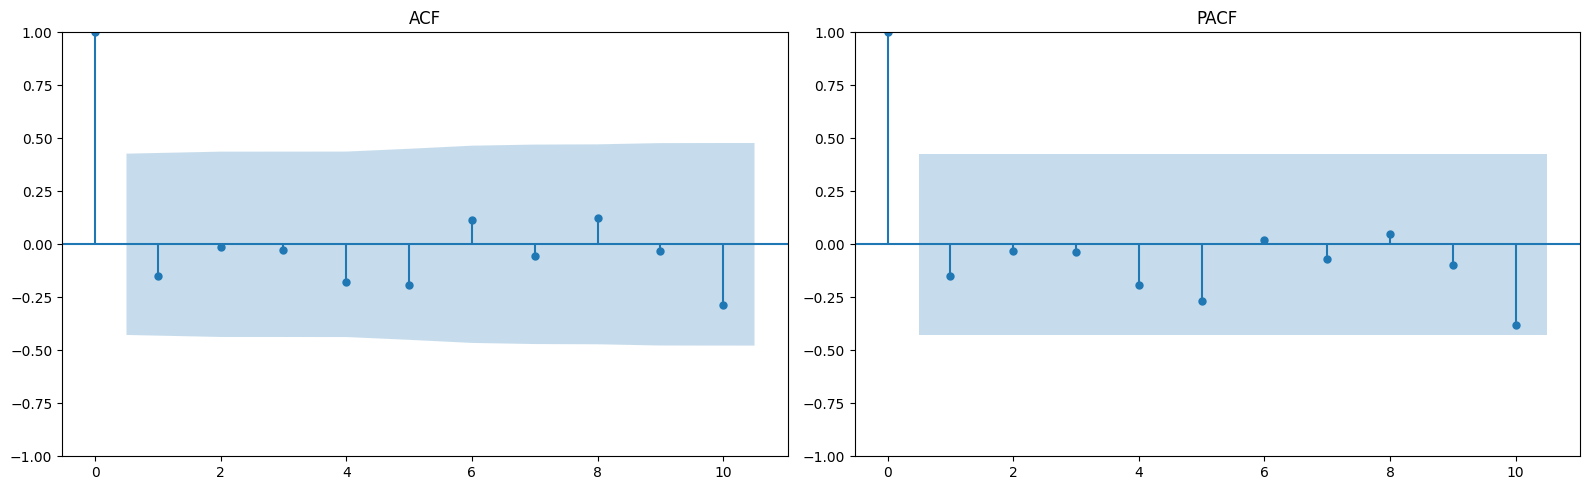

In [43]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(stationary_data, ax=axes[0])
axes[0].set_title('ACF')

plot_pacf(stationary_data, ax=axes[1])
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

Observations:
- ACF and PACF now show that we removed everything jajajajaja. Actually the data now resembles white noise with no predictible patterns, which I assume is probably very good. We can see that all lags are in the confidence interval.

# 5. Yearly/Monthly/Weekly/Daily Dynamics 

In [11]:
yearly_train = train.groupby(['year']).agg({
    'item_cnt_day' : 'sum'
}).reset_index()

monthly_train = train.groupby(['month']).agg({
    'item_cnt_day' : 'sum'
}).reset_index()

weekly_train = train.groupby(['week']).agg({
    'item_cnt_day' : 'sum'
}).reset_index()

daily_train = train.groupby(['day_of_week']).agg({
    'item_cnt_day' : 'sum'
}).reset_index()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

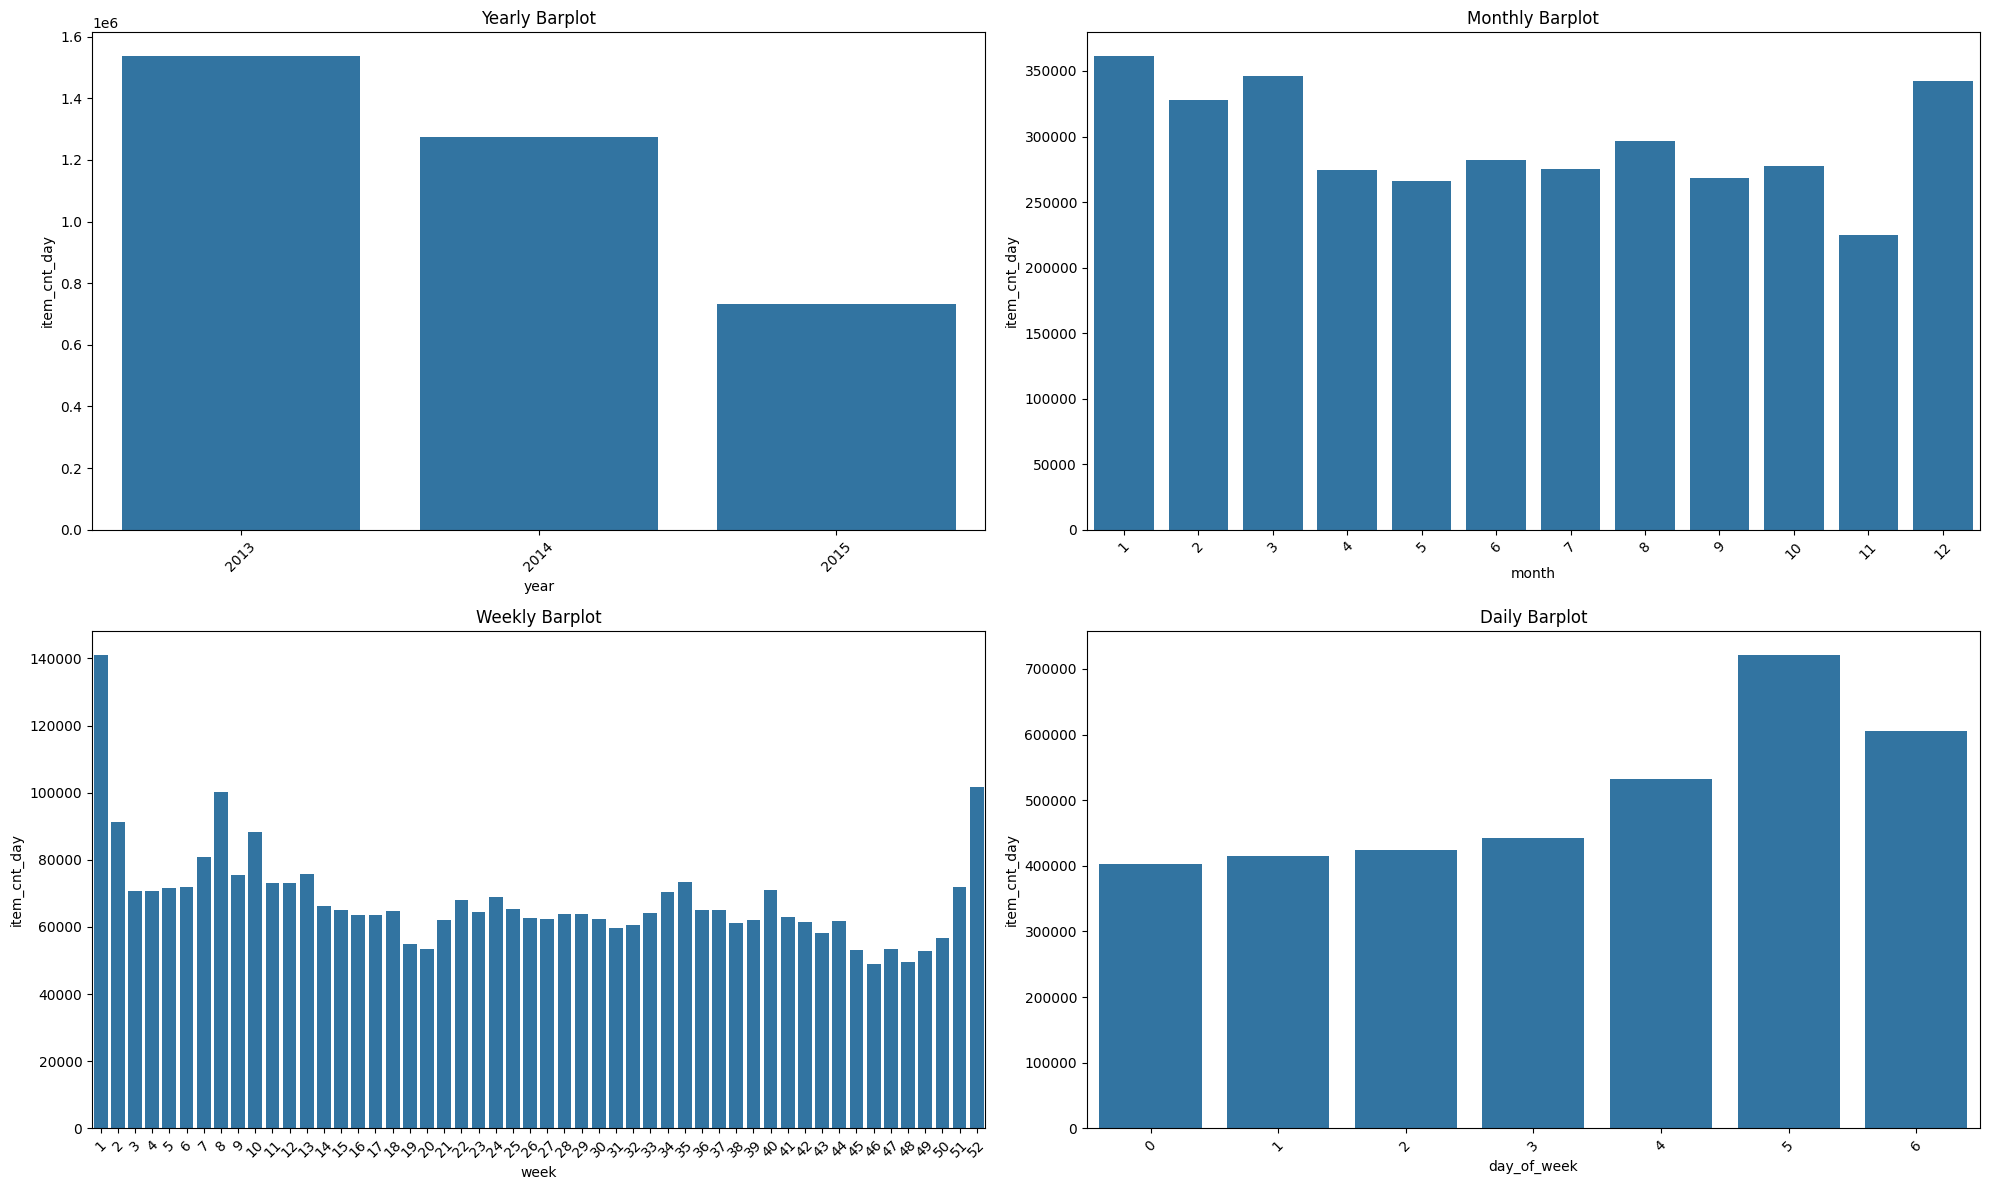

In [12]:
fig, axes = plt.subplots(2, 2, figsize = (20, 12))

sns.barplot(data=yearly_train, x='year', y='item_cnt_day', ax=axes[0,0])
axes[0,0].set_title('Yearly Barplot')
axes[0,0].tick_params('x', rotation=45)

sns.barplot(data=monthly_train, x='month', y='item_cnt_day', ax=axes[0,1])
axes[0,1].set_title('Monthly Barplot')
axes[0,1].tick_params('x', rotation=45)


sns.barplot(data=weekly_train, x='week', y='item_cnt_day', ax=axes[1,0])
axes[1,0].set_title('Weekly Barplot')
axes[1,0].tick_params('x', rotation=45)


sns.barplot(data=daily_train, x='day_of_week', y='item_cnt_day', ax=axes[1,1])
axes[1,1].set_title('Daily Barplot')
axes[1,1].tick_params('x', rotation=45)


plt.tight_layout()
plt.show()


Observation:
- Once again yearly barplot proves that sales have a tendency to decrease over the years
- Monthly barplot shows that over months sales are almost equal, though we have slight peaks in the beginning of the year (January-March) and in the end of the year (December)
- From weekly barplot we know that sales are also almost uniform through weeks, though there are slight peaks at week 8, week 40 and week 52 and a huge peek at week 1, which can also be important for the model to learn
- Daily barplot displays peaks on weekends (which is probably obvious), and most of purchases are made on Saturday

**Feature Engineering Ideas**
- I insist on creating cyclic feature (sin or cos) for *month* and *week* so that the model knows that January and December are closely related, as well as week 52 and week 1
- It might be useful to create *is_weekend* indicator, representing Saturday and Sunday (as most sales occur on this days)

    P.S. may be Friday should be taken into account as well
    
- Probably we now can drop *date_block_num* as it's not informative anymore

# 6. Categories Popularity 

In [13]:
gen_cats = train['item_category_name'].str.split('-').str[0]
train['gen_cat'] = gen_cats

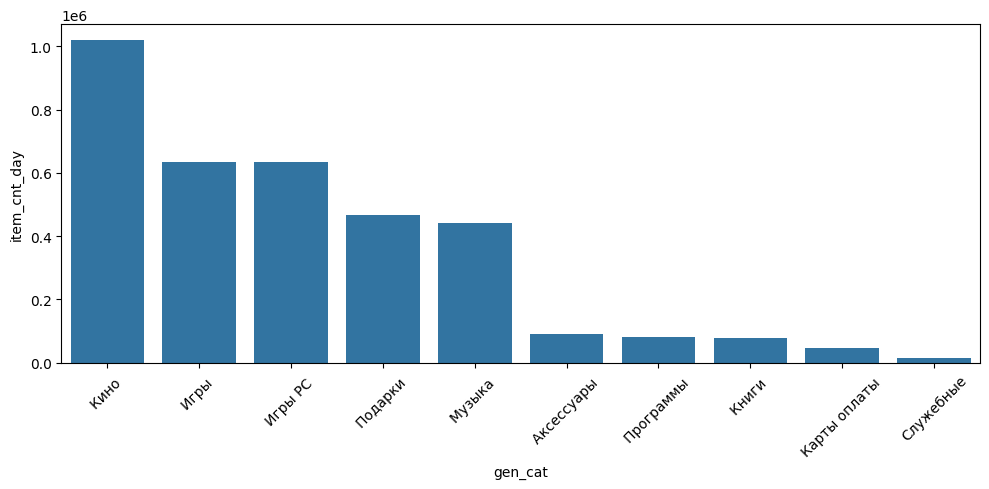

In [14]:
top_10_categories = train.groupby('gen_cat')['item_cnt_day'].sum().nlargest(10)
plt.figure(figsize=(10,5))
sns.barplot(top_10_categories)
plt.tick_params('x', rotation = 45)
plt.tight_layout()
plt.show()

Observation:
- At this section we see top-10 categories and can extract some interesting information. First of all we see a huge difference between top-5 and top-6 category (it's about 4 times as big), therefore we probably should get a better look at top-5 categories
- Here we clearly see that 'кино' is the most dominant category, ['игры рс','игры','подарки'] are sold almost in same amounts and 'музыка' is least sold in top-5 categories

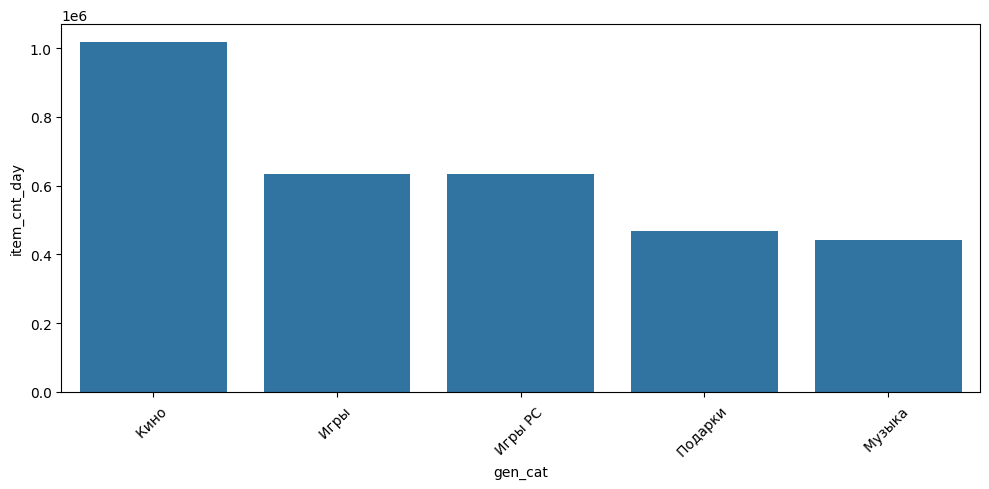

In [15]:
plt.figure(figsize=(10,5))
sns.barplot(top_10_categories[:5])
plt.tick_params('x', rotation = 45)
plt.tight_layout()
plt.show()

**Feature Engineering Ideas**
- I can assume that *gen_cat* feature seems to be more informative than original *item_category_name*, therefore I'd prefere to replace the second with the first one respectively
- Additionally we can probably benefit from some kind of *cat_popularity* indicator (i.e. ['most_popular', 'popular', 'less_popular', 'least_popular'])

# 7. Items Popularity
At this point, as we now know something about categories, it may be usefull for us to see if there are some specific items most likely to be bought

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


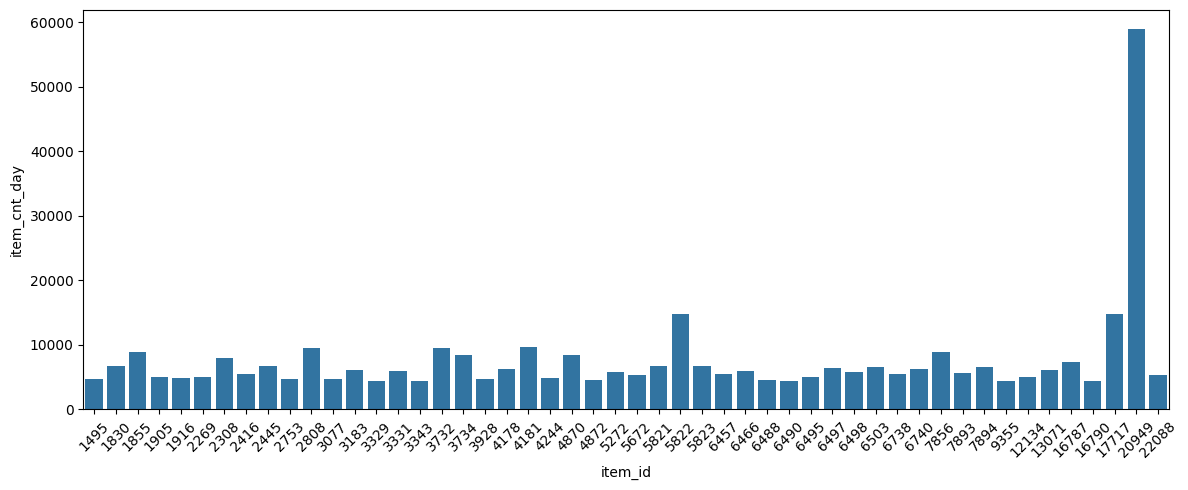

In [16]:
top_50_items = train.groupby(['item_id']).agg({
    'item_cnt_day' : 'sum'
}).reset_index()
top_50_items = top_50_items.sort_values(by = 'item_cnt_day', ascending = False)
plt.figure(figsize=(12,5))
sns.barplot(x=top_50_items['item_id'][:50], y=top_50_items['item_cnt_day'][:50])
plt.tick_params('x', rotation = 45)
plt.tight_layout()
plt.show()

Observation:
- Plotting top-50 bought items does not seem very informative, though I made an attempt to plot top-200 and top-500 items and, believe me, it was awfull to see ^-^. Nevertheless we can see that items in top-50 are in most cases bought uniformly. Though there is one strange item bought in general more than 175k times. tbh I'm not able to make any specific conclusions on this matter.

# 8. Shops Popularity
The last thing of popularity to be checked is shops, and I feel there can be something interesting

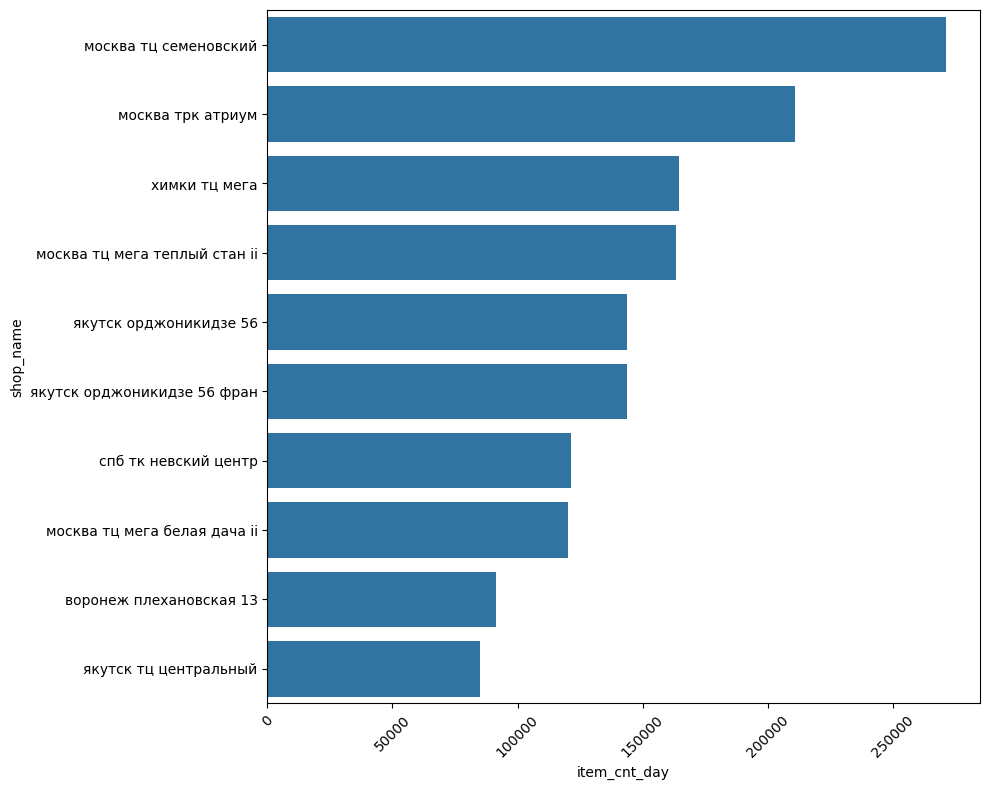

In [17]:
top_shops = train.groupby('shop_name')['item_cnt_day'].sum()
plt.figure(figsize=(10, 8))
sns.barplot(data=top_shops.nlargest(10), orient='h')
plt.tick_params('x', rotation=45)
plt.tight_layout()
plt.show()

Observations:
- As expected we can see some kind of 'popularity ranking' here. We see 2 stand outs: 'семеновский' and 'атриум' both in 'москва'. We can see some less popular shops and least popular in top-10. As we have only 60 unique shop names, let's better do the barplot for all the shops to the the general picture

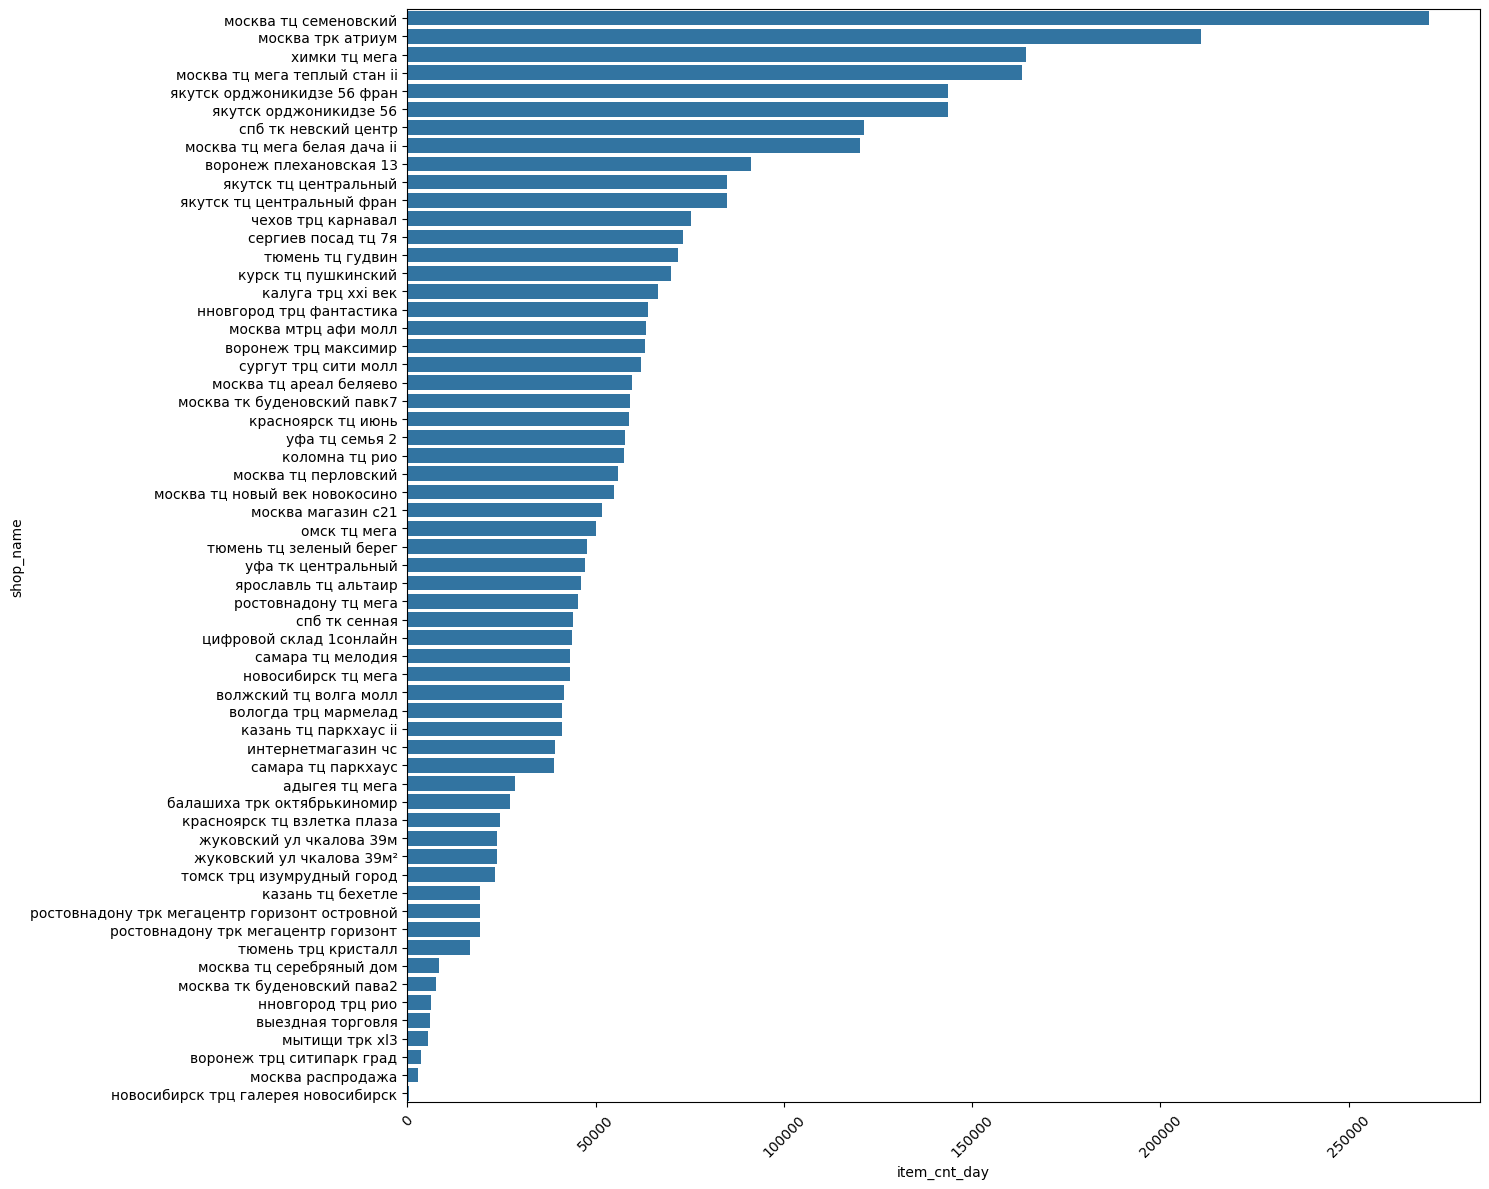

In [18]:
plt.figure(figsize=(15, 12))
sns.barplot(data=top_shops.sort_values(ascending=False), orient='h')
plt.tick_params('x', rotation=45)
plt.tight_layout()
plt.show()

- Oh yes we now clearly see that shops can be included in some 'popularity clusters'. And what is interesting - there are shops with 0 sells hmmm? Let's figure it out

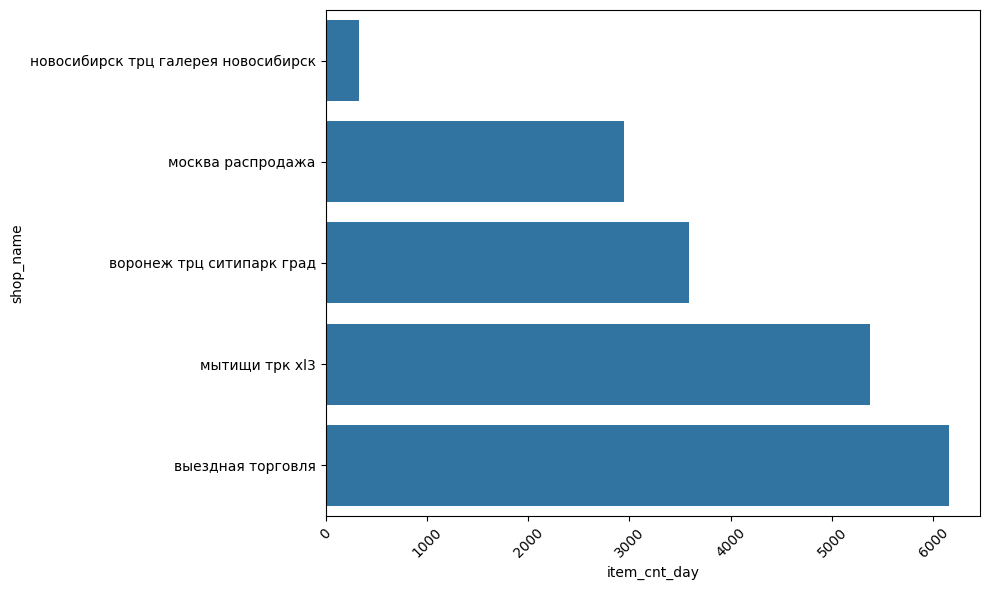

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_shops.nsmallest(5), orient='h')
plt.tick_params('x', rotation=45)
plt.tight_layout()
plt.show()

- Well in the previous plot the *figsize* value was just not big enough to see clearly, but now we can see that there are no shops with zero-sells. Anyways there is 1 shop with total sells less than 1k.

General conclusion: *shop_name* feature seems to have effect on purchases frequency, yet I dare to assume that the point is not just the shop, but the city it's located in. It's to be figured out later on.

**Feature Engeneering Ideas**
- Some kind of *shop_popularity* indicator might be useful(e.g. ['very_popular', 'popular', 'less_popular', 'unpopular']) 

# 9. City Popularity
Right after shop popularity analysis I came across an idea that may be it's not that shop popularity as city popularity, so let's plot top-city barplot

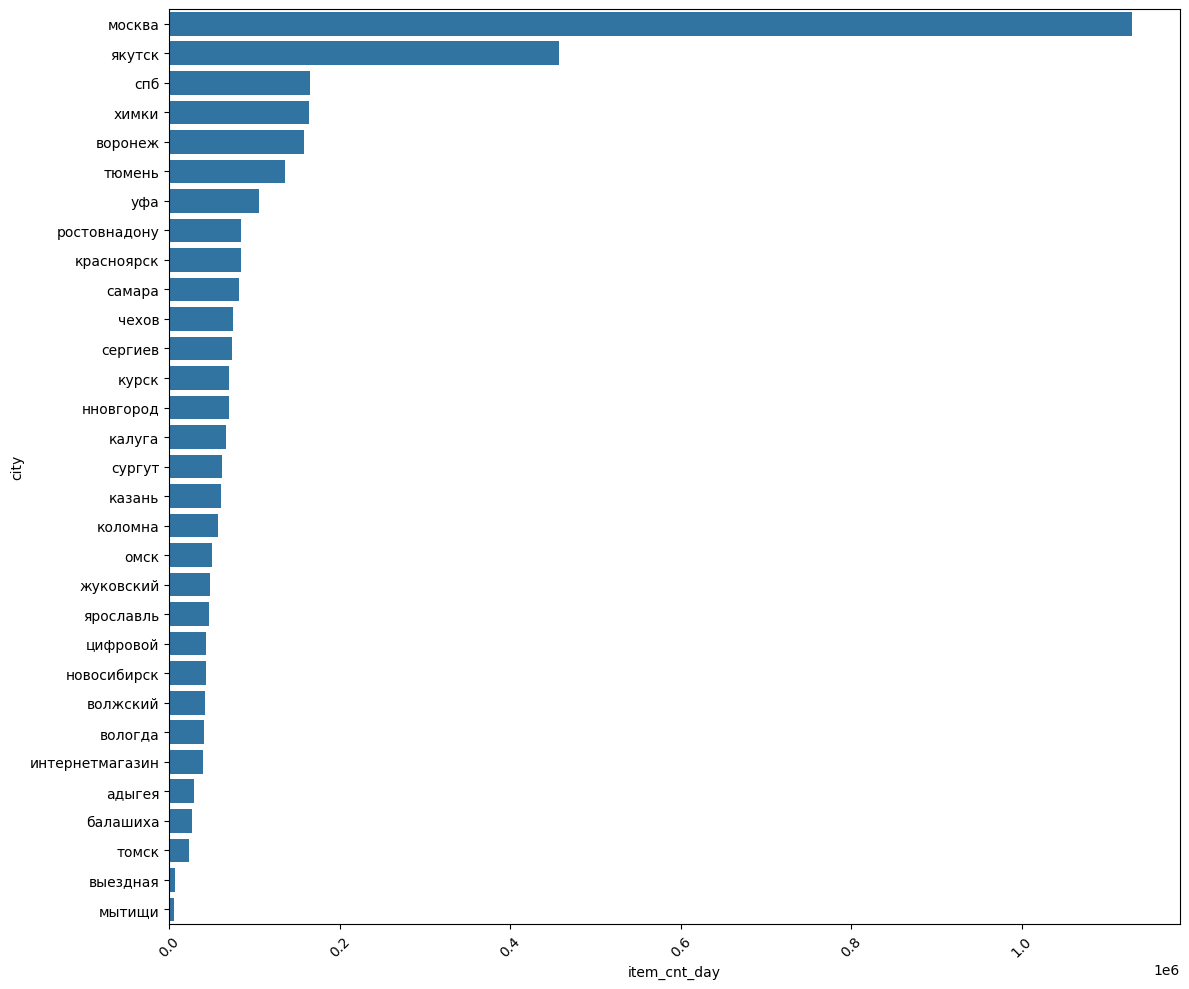

In [20]:
top_cities = train.groupby('city')['item_cnt_day'].sum()
plt.figure(figsize=(12, 10))
sns.barplot(data=top_cities.sort_values(ascending=False), orient='h')
plt.tick_params('x', rotation=45)
plt.tight_layout()
plt.show()

Observations:
- Wow! 'Москва' is a freaking selling giant with total sales of about 1.3kk items, that's huge. Well generally I have 2 assumptions. The first one is that people in 'Москва' tend to buy most of all. The second one is that 'Москва' has the largest number of shops. Let's check it out.

In [21]:
moskva_entries = train.loc[train['shop_name'].str.contains("москва", case=False), 'shop_name'].nunique()
yakutsk_entries = train.loc[train['shop_name'].str.contains("якутск", case=False), 'shop_name'].nunique()
moskva_entries, yakutsk_entries

(13, 4)

Observation:
- Well for clarity I decided to provide the number of shops containing top-2 city in it's names. The difference is huge. 'Москва' has 13 entries(which is almost 22% of all shops), whereas top-2 'якутск' has only 4 entries. I'm now really curious to know whether the number of shops effects or not.

In [22]:
from collections import defaultdict
cities_in_shops = defaultdict()
cities = list(train['city'].unique())

for city in cities:
    cities_in_shops[city] = train.loc[train['shop_name'].str.contains(city, case=False), 'shop_name'].nunique()


In [23]:
sorted(cities_in_shops.items(), key=lambda kv:kv[1], reverse=True)

[('москва', 13),
 ('якутск', 4),
 ('воронеж', 3),
 ('тюмень', 3),
 ('ростовнадону', 3),
 ('красноярск', 2),
 ('жуковский', 2),
 ('казань', 2),
 ('уфа', 2),
 ('нновгород', 2),
 ('спб', 2),
 ('омск', 2),
 ('самара', 2),
 ('новосибирск', 2),
 ('ярославль', 1),
 ('курск', 1),
 ('волжский', 1),
 ('адыгея', 1),
 ('балашиха', 1),
 ('коломна', 1),
 ('калуга', 1),
 ('интернетмагазин', 1),
 ('чехов', 1),
 ('химки', 1),
 ('сургут', 1),
 ('сергиев', 1),
 ('вологда', 1),
 ('цифровой', 1),
 ('выездная', 1),
 ('томск', 1),
 ('мытищи', 1)]

Observation:
- Well it seems like the number of shops in the city does not really matter, well than 'москва' is just a selling mutant ^-^

**Feature Engineering Ideas**
- Let's assume creating one more indicator for city popularity (e.g. ['very_popular', 'popular', 'unpopular']). The only thing to deal with is 'Москва', as it can spoil the division (by adding bias)

# 10. General Correlation Analysis

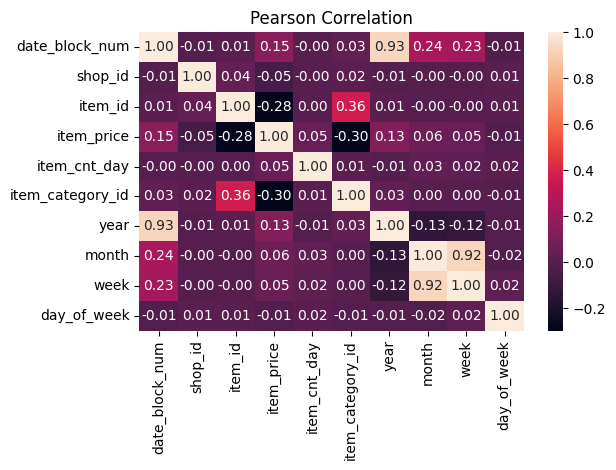

In [56]:
corr = train.corr(numeric_only=True)
sns.heatmap(corr, fmt = '.2f', annot=True)
plt.title('Pearson Correlation')
plt.tight_layout()
plt.show()

Observation:
- Let's begin with huge positive correlations. The first thing we see is *date_block_num* - *year* correlation(0.93), which is obvious as month order(as it is presented in this feature) is dependent on year. Then we see *item_id* - *item_category_id* correlation(0.37), which does not make any sense and should be fixed. Next we can see *month* - *date_block_num* correlation(0.24) and *week*-*date_block_num* correlation(0.23), and as it was mentioned far previously *date_block_num* is not informative and should be deleted so we should not pay attention at this correlation. Then we see *month* - *week*(0.93) correlation, which occurs because of the representation (both features are presented as consecutive integers)
- Now let's explore negative correlations. We see that slight *item_id* and *item_price* negative correlation(-0.13) which is actually ridicilous (higher *item_id* value = lower *item_price* value hmm???). Then we see *item_price* - *item_category_id* negative correlation(-0.25) which also does not make any sense. The funniest thing is *year* - *month* and *year* - *week* negative correlation (later years represent earlier months and weeks huh????)

**Feature Engineering Ideas**
- I guess at this point I can highlight those features I suppose to be not informative enough or may be even useless: *date_block_num*, *shop_id*, *item_id*, *item_category_id*. Preferable action is to drop these features and replace them with some of those proposed all over the notebook

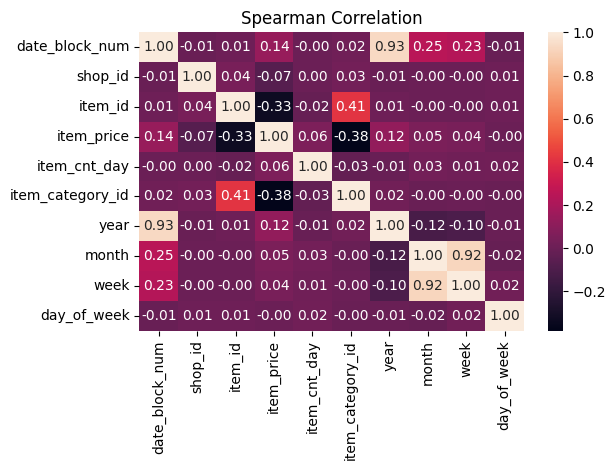

In [57]:
spearman_corr = train.corr(method='spearman', numeric_only=True)
sns.heatmap(spearman_corr, fmt='.2f', annot=True)
plt.title('Spearman Correlation')
plt.tight_layout()
plt.show()

**Final Feature Engineering Ideas**

Based on EDA here are some assumptions on creating new features and deleting reduntant respectively:
- Since the competition's goal is to predict monthly value of sales, we should aggregate data to translate *items_cnt_day* to *items_cnt_month*
- Since the data is skewed we can apply log-transformation to both *items_cnt_month* and *item_price*. In case we are not going to use tree-based models we can also apply scaling after log-transfromation
- Since most of sales happen in weekends we can create a *is_weekend* indicator for Saturday and Sunday (perhaps Friday as well)
- Since we have holidays-alike periods we can create a *is_holiday* indicator for some specific periods
- Since we sales tend to be very high in the beginning and in the end of the year we can create a *is_beginning/is_end* indicator
- Replace *day_of_week*, *week* and *month* with their cyclic options respectively
- Since prices are somehow 'clustered' we can create categoricals (e.g. 'cheap', 'mid-price', 'expensive') and replace regular prices with their 'clusters'. This might be much more informative
- We might find *gen_cat* to be more informative than original *item_category_name*
- Since items are somehow clustered by their categories popularity we can create a *item_popularity* indicator (e.g. 'popular', 'regular', 'not popular')
- Since shops have some kind of popularity we can create a *shop_popularity* indicator (e.g. 'popular', 'regular', 'not popular') 
- Since cities have some kind of popularity we can create a *city_popularity* indicator (e.g. 'popular', 'regular', 'not popular')
- Since time series is not stationary we have to apply log-transformation, differencing with period of 12 and 1-st order differencing, this way we'll get rid of predictable patterns

- We can drop *date_block_num*, *item_id*, *shop_id*, *item_category_id* since they are not too informative for us